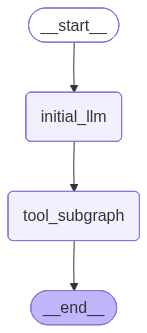


--- Running Main Graph with Sub-Graph ---
--- Main Graph: Initial LLM Call ---
--- Sub-Graph: Calling LLM with Tools ---
--- Sub-Graph: Calling LLM with Tools ---

--- Final Answer ---
The current weather in San Francisco, California, as per a recent update:

- **Temperature**: 12.2°C (54.0°F)
- **Condition**: Clear
- **Wind**: 4.9 mph (7.9 kph) from the NNE
- **Humidity**: 77%
- **Pressure**: 1021.0 mb
- **Visibility**: 16.0 km

Looking ahead to later today, the forecast indicates:

- **Day temperature**: 64°F
- **Night temperature**: 52°F
- **Precipitation chance**: 20%
- **Wind speed**: 12 mph
- **UV Index**: 11 (on a scale from 0 to 11+)

For more details, you can visit [Weather API](https://www.weatherapi.com/) and [Weather Shogun](https://weathershogun.com/weather/usa/ca/san-francisco/480/october/2025-10-29).


In [2]:
import os
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Sequence
import operator

# Core LangGraph components
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# LLM, tools, and messages
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from tavily import TavilyClient

# For displaying the graph image
from IPython.display import Image, display

# Load API keys and set up tracing
load_dotenv()
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "Intro to LangGraph"

# --- Define Tools ---
@tool
def search_tavily(query: str) -> str:
    """Searches the web for the user's query."""
    tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    results = tavily.search(query=query, max_results=2)
    return str(results['results'])

tools = [search_tavily]
tool_node = ToolNode(tools)

# --- Define State for the Sub-Graph ---
class ToolSubgraphState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

# --- Define Nodes for the Sub-Graph ---
def call_llm_with_tools(state: ToolSubgraphState):
    print("--- Sub-Graph: Calling LLM with Tools ---")
    llm = ChatOpenAI(model="gpt-4o")
    llm_with_tools = llm.bind_tools(tools)
    response = llm_with_tools.invoke(state['messages'])
    return {"messages": [response]}

def should_call_tool_subgraph(state: ToolSubgraphState):
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "call_tool"
    return END

# --- Build the Sub-Graph ---
tool_workflow = StateGraph(ToolSubgraphState)
tool_workflow.add_node("llm_with_tools", call_llm_with_tools)
tool_workflow.add_node("call_tool", tool_node)
tool_workflow.set_entry_point("llm_with_tools")
tool_workflow.add_conditional_edges("llm_with_tools", should_call_tool_subgraph)
tool_workflow.add_edge("call_tool", "llm_with_tools")
tool_subgraph = tool_workflow.compile()

# --- Define State for the Main Graph ---
class MainGraphState(TypedDict):
    input: str
    messages: Annotated[Sequence[BaseMessage], add_messages]

# --- Define Nodes for the Main Graph ---
def initial_llm_call(state: MainGraphState):
    print("--- Main Graph: Initial LLM Call ---")
    llm = ChatOpenAI(model="gpt-4o")
    response = llm.invoke([HumanMessage(content=state['input'])])
    return {"messages": [response]}

# --- Build the Main Graph ---
main_workflow = StateGraph(MainGraphState)
main_workflow.add_node("initial_llm", initial_llm_call)
main_workflow.add_node("tool_subgraph", tool_subgraph)
main_workflow.add_edge(START, "initial_llm")
main_workflow.add_edge("initial_llm", "tool_subgraph")
main_workflow.add_edge("tool_subgraph", END)

# Compile the main graph
app = main_workflow.compile()

# --- Display the Graph Image ---
# This generates a PNG image of the graph's structure
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not draw graph: {e}. Ensure pygraphviz and Pillow are installed.")


# --- Run the Graph ---
print("\n--- Running Main Graph with Sub-Graph ---")
final_state = app.invoke({"input": "What's the weather in San Francisco?"})

print("\n--- Final Answer ---")
print(final_state['messages'][-1].content)